# Galton-Watson Branching Processes

Start with one individual. It has a random number of children. Each of those has a random
number of children, and so on. $X[n]$ is the size of generation $n$:

$$X[n+1] = \text{sum of } X[n] \text{ independent draws from the offspring distribution}$$

Galton and Watson invented this in the 1870s asking why aristocratic surnames kept
disappearing. The answer turns entirely on the **mean number of children** $m$:

- $m < 1$ (*subcritical*) -- the line dies out, certainly.
- $m = 1$ (*critical*) -- it still dies out certainly, but it can take a very long time.
- $m > 1$ (*supercritical*) -- it may die out, but with positive probability it grows forever.

That sharp threshold at exactly 1 is the point of the model. It reappears in epidemics,
where $m$ is the reproduction number and the same cutoff separates an outbreak that fizzles
out from one that spreads.

In [1]:
from symbulate import *

## Create a process and draw a family tree

`offspring_dist` is how many children one individual has. It has to be a discrete
distribution on 0, 1, 2, ... -- `Poisson` and `Binomial` are the usual choices.

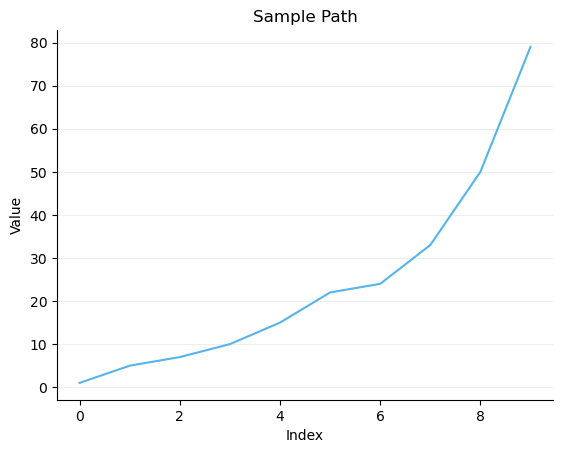

In [2]:
X = GaltonWatson(offspring_dist=Poisson(1.5))
X.draw().plot()

## Simulate and plot several family trees

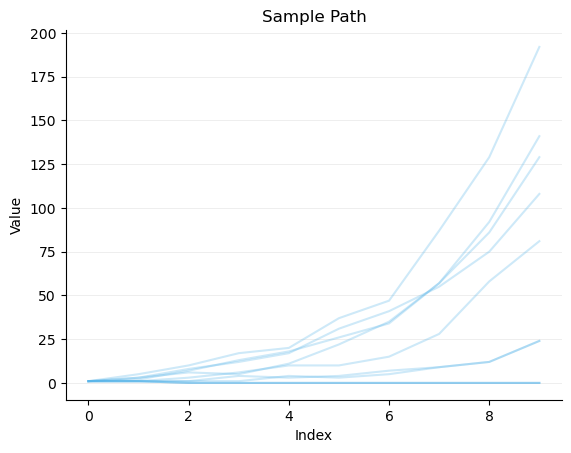

In [3]:
X.sim(10).plot()

Some lines die out almost immediately; others take off. That spread is the whole story of a
supercritical process.

## The expected size of a generation

Every individual has $m$ children on average, so a generation is $m$ times the size of the
one before it: $E[X[n]] = m^n$.

In [4]:
for n in [1, 2, 3, 4]:
    print("generation", n, " average size", round(X[n].sim(5000).mean(), 2),
          " theory", round(1.5**n, 2))

generation 1  average size 1.51  theory 1.5
generation 2  average size 2.26  theory 2.25


generation 3  average size 3.35  theory 3.38


generation 4  average size 5.24  theory 5.06


## The threshold at one child

Below 1 the expected size shrinks geometrically; above 1 it grows. Watch the difference.

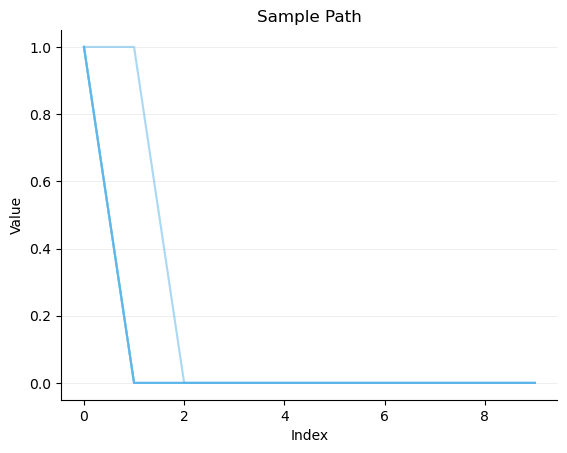

In [5]:
GaltonWatson(offspring_dist=Poisson(0.7)).sim(10).plot()   # subcritical

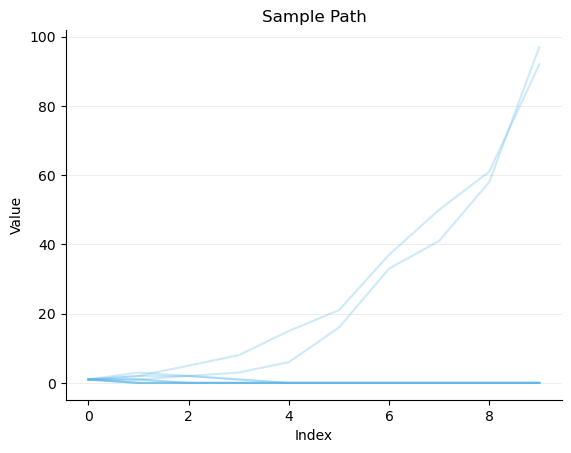

In [6]:
GaltonWatson(offspring_dist=Poisson(1.6)).sim(10).plot()   # supercritical

## Does the line survive?

A path has died out by generation $n$ when $X[n] = 0$. `apply` runs a function over the
whole family tree, so asking is one line.

In [7]:
for m in [0.7, 1.0, 1.5, 2.0]:
    Y = GaltonWatson(offspring_dist=Poisson(m))
    extinct = Y.apply(lambda path: int(path[15]) == 0).sim(2000).mean()
    print("m =", m, " P(extinct by generation 15) =", round(extinct, 3))

m = 0.7  P(extinct by generation 15) = 0.998


m = 1.0  P(extinct by generation 15) = 0.881


m = 1.5  P(extinct by generation 15) = 0.428


Simulating... [███████████████████░░░░░░░░░░░] 1312/2000 (65%)

Simulating... [███████████████████░░░░░░░░░░░] 1320/2000 (66%)

...

Simulating... [█████████████████████████████░] 1960/2000 (98%)

Simulating... [█████████████████████████████░] 1980/2000 (99%)

Simulating... [██████████████████████████████] 2000/2000 (100%)

Simulating... [██████████████████████████████] 2000/2000 (100%)

m = 2.0  P(extinct by generation 15) = 0.196


For $m \le 1$ extinction is certain -- the numbers below 1 there are only because 15
generations is not forever, and the critical case $m = 1$ is famously slow.

For $m > 1$ the probability settles at a value strictly below 1. For Poisson offspring it
is the solution of $s = e^{m(s-1)}$, which for $m = 1.5$ is about **0.417** and for
$m = 2$ about **0.203**.

## Starting with more than one individual

Each starting individual founds its own independent line, so the expected size scales
directly and extinction needs *every* line to die out -- much less likely.

In [8]:
Z = GaltonWatson(offspring_dist=Poisson(1.2), initial=10)
print("E[X[3]] =", round(Z[3].sim(5000).mean(), 2), " theory", round(10 * 1.2**3, 2))

E[X[3]] = 17.54  theory 17.28


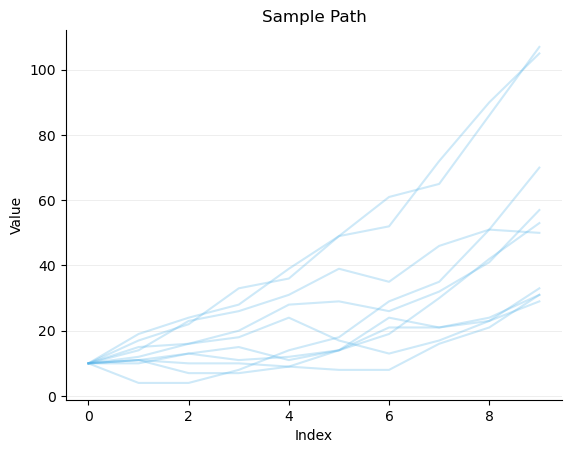

In [9]:
Z.sim(10).plot()

## Extinction is final

Once a generation is empty there is nobody left to have children, so every later generation
is empty too. Symbulate short-circuits this, which is why reading far into an extinct tree
costs nothing.

In [10]:
dead = GaltonWatson(offspring_dist=Binomial(1, 0)).draw()   # nobody has children
[int(dead[n]) for n in [0, 1, 2, 1000, 100000]]

[1, 0, 0, 0, 0]

The opposite case is worth a warning. A supercritical tree really does explode: generation
$n$ takes about $m^n$ draws to produce, so asking for generation 100 of a process with
$m = 2$ is asking for $2^{100}$ individuals. That is the process behaving correctly, not a
bug -- but keep the generation numbers modest when $m$ is much above 1.